In [16]:
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import accuracy_score, average_precision_score, f1_score, classification_report
from xgboost import XGBClassifier
from column_groups import model_a_feature_cols, model_b_feature_cols
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
# grab the data
df = pd.read_parquet("targets_features_split.parquet")
train, val, test = df["split"].eq("train"), df["split"].eq("val"), df["split"].eq("test")

In [4]:
cancel_col = "is_cancelled" if "is_cancelled" in df.columns else "target_cancelled"
delay_col = "is_delayed" if "is_delayed" in df.columns else "target_delayed"

# adding extra seasonal and lag features to help Model A catch cancellations
extra_features = [
    "month_sin", "month_cos", "dow_sin", "dow_cos", 
    "is_summer", "is_holiday_season", "lag1_delay_rate", "lag1_volume"
]
model_a_final = list(dict.fromkeys(model_a_feature_cols + extra_features))
model_a_final = [c for c in model_a_final if c in df.columns and "lag2" not in c] 
model_b_final = [c for c in model_b_feature_cols if c in df.columns]

# prep model a data (all flights)
x_train_a, y_train_a = df.loc[train, model_a_final], df.loc[train, cancel_col].astype(int)
x_test_a, y_test_a = df.loc[test, model_a_final], df.loc[test, cancel_col].astype(int)

# prep model b data (only flights that actually took off)
train_b = train & (df[cancel_col] == 0)
test_b = test & (df[cancel_col] == 0)

x_train_b, y_train_b = df.loc[train_b, model_b_final], df.loc[train_b, delay_col].astype(int)
x_test_full = df.loc[test, model_b_final]
y_test_multi = df.loc[test, "target"].astype(int)

print(f"Model A features: {len(model_a_final)}")
print(f"Model B features: {len(model_b_final)}")

Model A features: 53
Model B features: 48


In [7]:
# calculating cancellation rate percent 
cancel_pct = (y_train_a.sum() / len(y_train_a)) * 100
print(f"Cancellation rate (training): {cancel_pct:.2f}%\n")

Cancellation rate (training): 1.76%



In [8]:
# focal loss
# tells model to pay attention to rare class 
FOCAL_GAMMA = 2.0

def xgb_focal_loss(y_true, y_pred):
    # converting model predictions into probabilities
    p = np.clip(1.0 / (1.0 + np.exp(-y_pred)), 1e-7, 1 - 1e-7)
    
    # calculate gradient and hessian with focal weight
    w = np.where(y_true == 1, (1 - p)**FOCAL_GAMMA, p**FOCAL_GAMMA)
    grad = w * (p - y_true)
    hess = np.maximum(w * p * (1 - p), 1e-7) 
    return grad, hess

In [10]:
# Model A: Canelled vs. non-Cancelled
# imbalance ratio for cancelled flights
# best_score_a, best_model_a = -1.0, None
# spw_mult_a = 0.710174  (from bayesian_hyperparams)
#
# for mult in [0.75, 1.0, 1.25]:
#     for max_delta_step in [5]:
#         model = XGBClassifier(
#             n_estimators=6000, 
#             max_depth=3, 
#             learning_rate=0.07328, 
#             min_child_weight=2.774,
#             subsample=0.9306, 
#             colsample_bytree=0.7908, 
#             gamma=6.15e-07, 
#             reg_alpha=1.94e-06, 
#             reg_lambda=0.1965,
#             scale_pos_weight=base_ratio_a * spw_mult_a * mult, 
#             max_delta_step=max_delta_step, 
#             objective=xgb_focal_loss, 
#             random_state=42, 
#             n_jobs=-1
#         )
#         # early stopping to prevent overfitting
#         model.fit(x_train_a, y_train_a, eval_set=[(x_test_a, y_test_a)], early_stopping_rounds=120, verbose=False)
#         
#         # keep the model with the best pr-auc
#         pr_auc = average_precision_score(y_test_a, model.predict_proba(x_test_a)[:, 1])
#         if pr_auc > best_score_a:
#             best_score_a, best_model_a = pr_auc, model

## For Live Demo
best_model_a = XGBClassifier()

best_model_a.load_model("cascade_model_a.ubj")

Best Model A PR-AUC: 0.1360


In [11]:
# delay percentage
delay_pct = (y_train_b.sum() / len(y_train_b)) * 100
print(f"Delay Rate in Training Data: {delay_pct:.2f}%\n")

Delay Rate in Training Data: 18.73%



In [12]:
## Model B: delays vs. on-time
# imbalance ratio for delays
base_ratio_b = float((1 - y_train_b).sum() / max(y_train_b.sum(), 1))
best_score_b, best_model_b = -1.0, None

# grid for multipliers
for mult in [0.75, 1.0, 1.25]:
    for max_delta_step in [2]:
        model = XGBClassifier(
            n_estimators=1000, max_depth=10, learning_rate=0.010, min_child_weight=29.93,
            subsample=0.60, colsample_bytree=0.59, scale_pos_weight=base_ratio_b * mult, 
            max_delta_step=max_delta_step, objective="binary:logistic", random_state=42, n_jobs=-1
        )
        model.fit(x_train_b, y_train_b)
        
        # we optimize for F1 since delays are more balanced
        y_test_b = df.loc[test_b, delay_col].astype(int)
        preds = (model.predict_proba(x_test_full.loc[test_b])[:, 1] >= 0.5).astype(int)
        f1 = f1_score(y_test_b, preds, average='macro')
        
        if f1 > best_score_b:
            best_score_b, best_model_b = f1, model

print(f"Best Model B Macro-F1: {best_score_b:.4f}")

Best Model B Macro-F1: 0.6192


In [13]:
### Tuning for cascade ---> Isotonic 
# isotonic regression to fix skewed probabilities
cal_a = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0).fit(best_model_a.predict_proba(x_train_a)[:, 1], y_train_a)
cal_b = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0).fit(best_model_b.predict_proba(x_train_b)[:, 1], y_train_b)

p_test_a = cal_a.predict(best_model_a.predict_proba(x_test_a)[:, 1])
p_test_b = cal_b.predict(best_model_b.predict_proba(x_test_full)[:, 1])

# grid for different thresholds
best_hard_f1, best_thr_a, best_thr_b = -1.0, 0.5, 0.5
grid = np.linspace(0.01, 0.95, 181)

# grid for different thresholds for model A
for ta in [0.02, 0.05, 0.1]:  
    for tb in grid[::10]:    # thresholds for model B
        y_pred = np.where(p_test_a >= ta, 2, (p_test_b >= tb).astype(int)).astype(int)
        score = f1_score(y_test_multi, y_pred, average="macro")
        if score > best_hard_f1:
            best_hard_f1, best_thr_a, best_thr_b = score, ta, tb

# grid for soft cascade weights
best_soft_f1, best_w_delay, best_w_cancel = -1.0, 1.0, 1.0
weight_grid = [0.70, 0.85, 1.00, 1.15, 1.30]

# turn two binary probabilities into three-class scores
p_cancel = p_test_a
p_delay = (1.0 - p_cancel) * p_test_b
p_ontime = (1.0 - p_cancel) * (1.0 - p_test_b)
base_scores = np.column_stack([p_ontime, p_delay, p_cancel])

for wd in weight_grid:
    for wc in weight_grid:
        scores = base_scores.copy()
        scores[:, 1] *= wd
        scores[:, 2] *= wc
        y_pred = scores.argmax(axis=1)
        score = f1_score(y_test_multi, y_pred, average="macro")
        if score > best_soft_f1:
            best_soft_f1, best_w_delay, best_w_cancel = score, wd, wc

# pick whichever cascade method did better
if best_soft_f1 > best_hard_f1:
    print("Soft cascade is better")
    final_preds = (base_scores * [1.0, best_w_delay, best_w_cancel]).argmax(axis=1)
else:
    print("Hard cascade is better")
    final_preds = np.where(p_test_a >= best_thr_a, 2, (p_test_b >= best_thr_b).astype(int)).astype(int)

Hard cascade is better


In [14]:
# cascade results
print("Test Accuracy:", accuracy_score(y_test_multi, final_preds))
print("Test Macro-F1:", f1_score(y_test_multi, final_preds, average="macro"))
print("\nClassification Report (0=On-Time, 1=Delayed, 2=Cancelled):")
print(classification_report(y_test_multi, final_preds, digits=4))

Test Accuracy: 0.7051286295819713
Test Macro-F1: 0.46697231785063426

Classification Report (0=On-Time, 1=Delayed, 2=Cancelled):
              precision    recall  f1-score   support

           0     0.8246    0.8078    0.8161   3091391
           1     0.3834    0.4111    0.3968    863057
           2     0.1876    0.1885    0.1880    123191

    accuracy                         0.7051   4077639
   macro avg     0.4652    0.4691    0.4670   4077639
weighted avg     0.7119    0.7051    0.7084   4077639



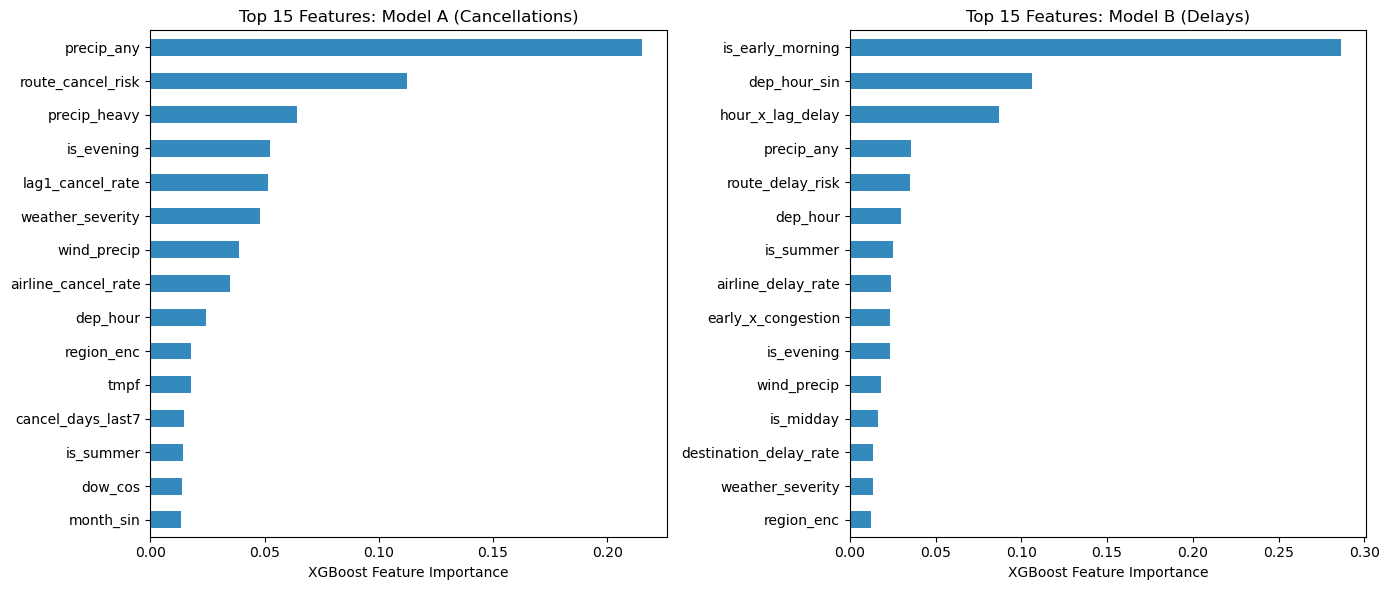

In [17]:
# feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, title in zip(
    axes, 
    [best_model_a, best_model_b], 
    ['Model A (Cancellations)', 'Model B (Delays)']
):
    importances = pd.Series(model.feature_importances_, index=model.feature_names_in_)
    importances.nlargest(15).sort_values().plot(kind='barh', ax=ax, color='#348ABD')
    ax.set_title(f"Top 15 Features: {title}")
    ax.set_xlabel("XGBoost Feature Importance")

plt.tight_layout()
plt.show()